In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt


3408 articles
↓
UMAP → (3408,5)

↓
HDBSCAN
38 clusters
447 noise

↓
BERTopic
42 topics

In [2]:
DATA_DIR = Path("data")
WORKING_DATA = DATA_DIR / "sampled_lancet_psychiatry_1000_preprcessing_skitlearn.csv"
AIM_TXT = DATA_DIR / "aim_scope.txt"
ARTICLE_EMBEDDINGS = DATA_DIR / "article_embeddings.npy"
AIM_EMBEDDING = DATA_DIR / "aim_embedding.npy"
SIMILARITY_CSV = DATA_DIR / "article_similarity_scores.csv"
EMBEDDING_2D_CSV = DATA_DIR / "viz_embeddings_2d.csv"

In [3]:
import warnings

articles = pd.read_csv(WORKING_DATA)
article_embeddings = np.load(ARTICLE_EMBEDDINGS)
aim_embedding = np.load(AIM_EMBEDDING)

articles["title"] = articles["title"].fillna("").astype(str)
articles["abstract"] = articles["abstract"].fillna("").astype(str)
articles["doc"] = (articles["title"] + " " + articles["abstract"]).str.replace(r"\s+", " ", regex=True).str.strip()

print("articles shape:", articles.shape)
print("article embeddings shape:", article_embeddings.shape)
print("aim embedding shape:", aim_embedding.shape)

n_articles = len(articles)
n_embeddings = article_embeddings.shape[0]

if n_articles == n_embeddings:
    pass
elif n_embeddings < n_articles:
    warnings.warn(f"Embedding rows ({n_embeddings}) < CSV rows ({n_articles}). Truncating articles to first {n_embeddings} rows.")
    articles = articles.iloc[:n_embeddings].reset_index(drop=True)
else:
    raise AssertionError(f"Embedding rows ({n_embeddings}) > CSV rows ({n_articles}). Check that you're loading the correct files.")
print("adjusted articles shape:", articles.shape)
print("article embeddings shape:", article_embeddings.shape)
articles.head(3)

articles shape: (519, 8)
article embeddings shape: (519, 384)
aim embedding shape: (384,)
adjusted articles shape: (519, 8)
article embeddings shape: (519, 384)


,pmid,title,abstract,year,doi,authors,journal,doc
0,41115444,psychotic symptoms during pharmacological trea...,personal view address key questions support ev...,2026,10.1016/S2215-0366(25)00248-2,Cortese S; Garcia-Argibay M; Oliver D; Chang Z...,The lancet. Psychiatry,psychotic symptoms during pharmacological trea...
1,35598606,trajectories and predictors of perinatal depre...,background gaps understanding longitudinal pat...,2022,10.1016/S2215-0366(22)00110-9,Larsen A; Pintye J; Marwa MM; Watoyi S; Kinuth...,The lancet. Psychiatry,trajectories and predictors of perinatal depre...
2,40967728,weight trajectories and access to weight manag...,background excess weight common people severe ...,2025,10.1016/S2215-0366(25)00212-3,Lee CL; Gao M; Smith MC; Dong X; Waite F; Avey...,The lancet. Psychiatry,weight trajectories and access to weight manag...


In [4]:
from similarity import cosine_similarity


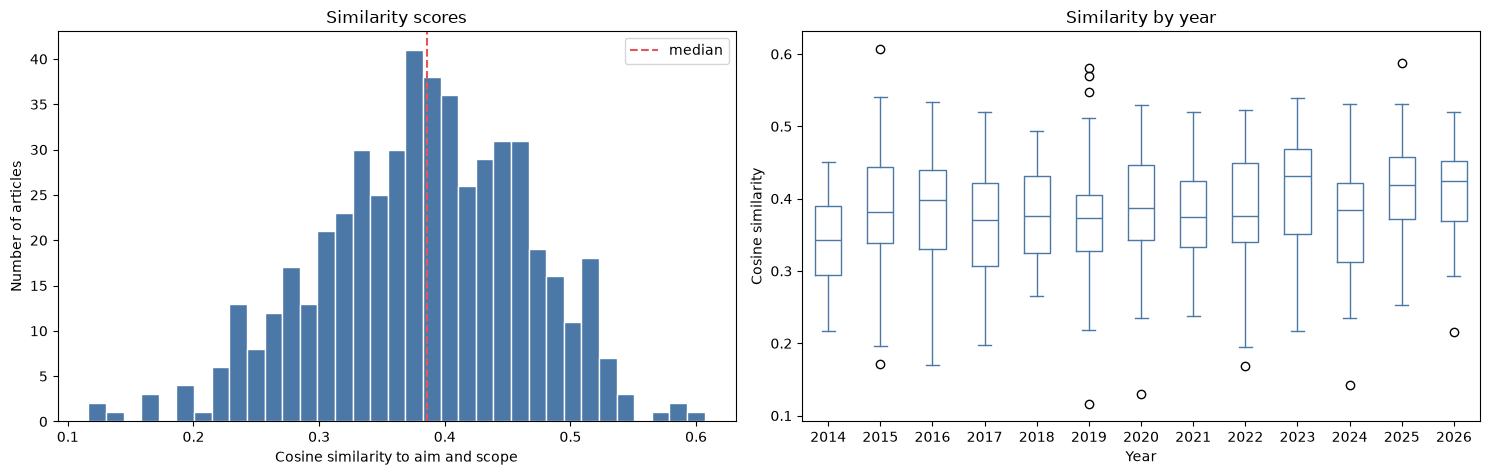

In [5]:
# Recalculate similarity from the saved embeddings so the notebook is self-contained.
aim_vector = aim_embedding.reshape(1, -1)
articles["similarity_to_aim"] = cosine_similarity(article_embeddings, aim_vector).ravel()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(articles["similarity_to_aim"], bins=35, color="#4C78A8", edgecolor="white")
axes[0].axvline(articles["similarity_to_aim"].median(), color="#E15759", linestyle="--", label="median")
axes[0].set_title("Similarity scores")
axes[0].set_xlabel("Cosine similarity to aim and scope")
axes[0].set_ylabel("Number of articles")
axes[0].legend()

articles.boxplot(column="similarity_to_aim", by="year", ax=axes[1], grid=False, color="#4C78A8")
axes[1].set_title("Similarity by year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Cosine similarity")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [6]:
import textwrap

In [7]:
def short_text(value, width=130):
    return textwrap.shorten(str(value), width=width, placeholder="...")

show_cols = ["pmid", "year", "similarity_to_aim", "title"]

top_articles = articles.sort_values("similarity_to_aim", ascending=False)[show_cols].copy()
bottom_articles = articles.sort_values("similarity_to_aim", ascending=True)[show_cols].copy()

top_articles["title"] = top_articles["title"].map(short_text)
bottom_articles["title"] = bottom_articles["title"].map(short_text)

print("Most aligned with the journal aim and scope")
display(top_articles.head(10))

print("Least aligned with the journal aim and scope")
display(bottom_articles.head(10))

Most aligned with the journal aim and scope


,pmid,year,similarity_to_aim,title
518,26360901,2015,0.606866,detection and treatment of at-risk mental stat...
476,39952266,2025,0.587713,drug development in psychiatry: 50 years of fa...
376,31777340,2019,0.580542,clinical and social factors associated with in...
235,31296444,2019,0.569059,perspectives on icd-11 to understand and impro...
202,30744997,2019,0.547768,interventions to reduce symptoms of common men...
393,26360450,2015,0.540357,the management of adult psychiatric emergencie...
311,37774723,2023,0.539150,antidepressant and antipsychotic side-effects ...
366,26573970,2016,0.533126,charting the landscape of priority problems in...
162,26296562,2015,0.531233,clinical effectiveness and cost-effectiveness ...
209,38879276,2024,0.530760,psychological and psychosocial interventions f...


Least aligned with the journal aim and scope


,pmid,year,similarity_to_aim,title
396,30340985,2019,0.116402,how to inform the public about protective acti...
487,32861267,2020,0.130142,the psychology of protecting the uk public aga...
447,39300640,2024,0.142623,adverse outcomes and mortality in individuals ...
166,35143759,2022,0.168020,structural brain measures among children with ...
391,27639661,2016,0.169597,"cognitive, behaviour, and academic functioning..."
52,26303557,2015,0.171037,medical marijuana laws and adolescent marijuan...
17,27374072,2016,0.189103,why it is probably too soon to assess the publ...
347,36087610,2022,0.195484,maternal infection during pregnancy and likeli...
120,26462226,2015,0.196367,bullying in the family: sibling bullying
243,29033006,2017,0.198298,relative age within the school year and diagno...


In [8]:
embeddings_2d = pd.read_csv(EMBEDDING_2D_CSV)
aim_2d = embeddings_2d.iloc[-1]
articles_2d = embeddings_2d.iloc[:-1]

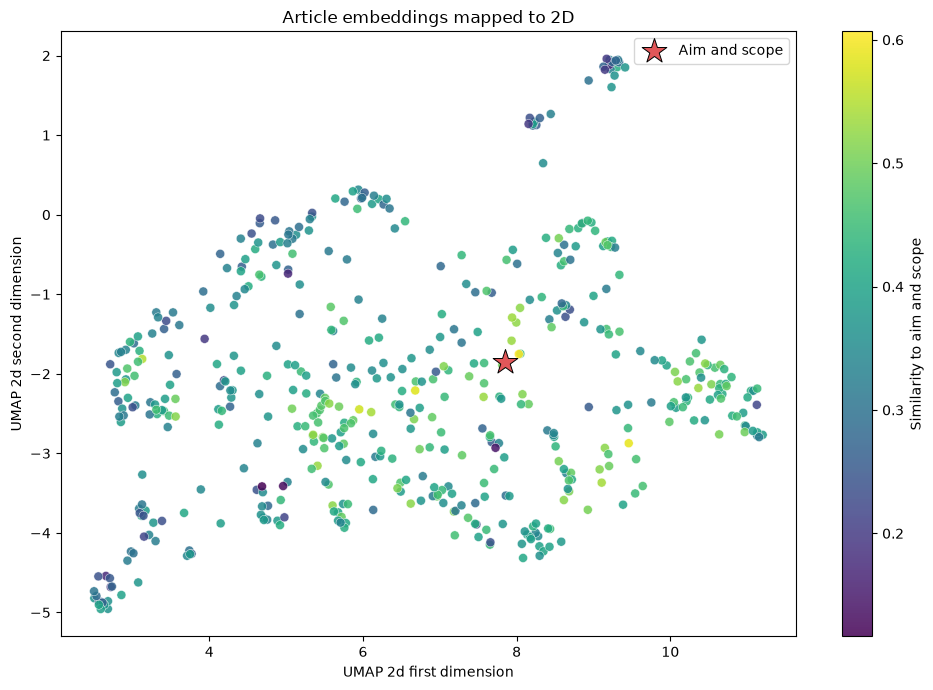

In [9]:
# Extract aim coordinates from aim_2d
aim_x = aim_2d["UMAP1"]
aim_y = aim_2d["UMAP2"]

# Add x and y columns to articles dataframe
articles["x"] = articles_2d["UMAP1"].values
articles["y"] = articles_2d["UMAP2"].values

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    articles["x"],
    articles["y"],
    c=articles["similarity_to_aim"],
    cmap="viridis",
    s=42,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.35,
)
ax.scatter([aim_x], [aim_y], marker="*", s=350, color="#E15759", edgecolor="black", linewidth=0.7, label="Aim and scope")
ax.set_title("Article embeddings mapped to 2D")
ax.set_xlabel("UMAP 2d first dimension")
ax.set_ylabel("UMAP 2d second dimension")
ax.legend(loc="best")
plt.colorbar(scatter, ax=ax, label="Similarity to aim and scope")
plt.tight_layout()
plt.show()


In [10]:
from bertopic_articles import hdbscan_articles


/Users/skaiyrin/GenAi/scijo_nlp/scijonlp26/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8216.93it/s]


In [11]:
hdbscan_model, cluster_labels = hdbscan_articles(articles_2d)

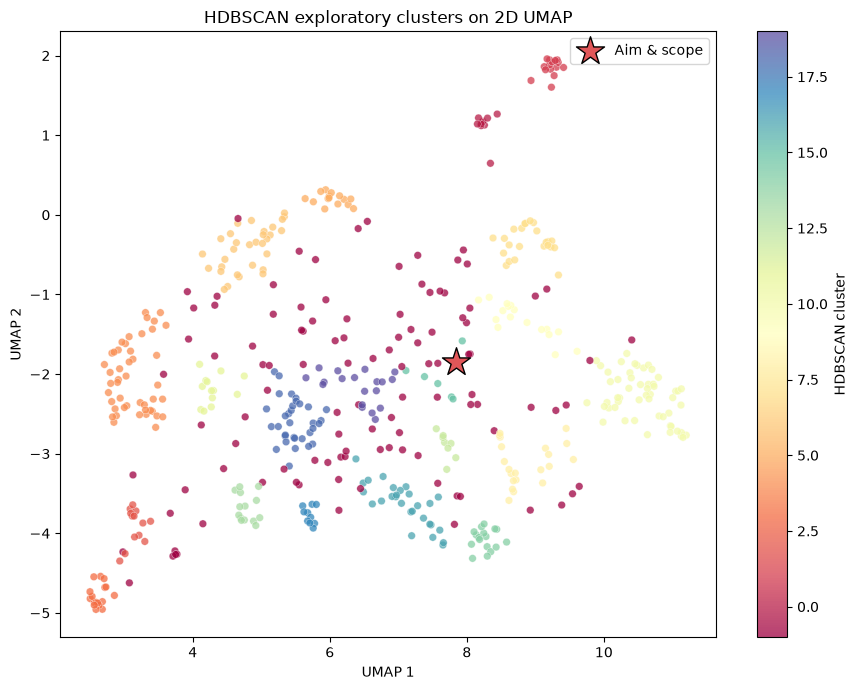

HDBSCAN clusters: 20 | noise points: 109


In [12]:
# Ensure labels are available for current 2D points
hdbscan_model, cluster_labels = hdbscan_articles(articles_2d)

# Reuse existing dataframe/coordinates already prepared in the notebook
articles["hdbscan_cluster"] = cluster_labels
AIM_COLOR = "#E15759"

fig, ax = plt.subplots(figsize=(9, 7))

clusters = articles["hdbscan_cluster"].values
sc = ax.scatter(
    articles["x"],
    articles["y"],
    c=clusters,
    cmap="Spectral",
    alpha=0.75,
    s=30,
    edgecolors="white",
    linewidths=0.3,
)
plt.colorbar(sc, ax=ax, label="HDBSCAN cluster")
ax.scatter(
    [aim_x],
    [aim_y],
    marker="*",
    s=450,
    c=AIM_COLOR,
    edgecolors="black",
    linewidths=1,
    label="Aim & scope",
)

ax.set_title("HDBSCAN exploratory clusters on 2D UMAP")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend()
plt.tight_layout()
plt.show()

n_topics = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = int((clusters == -1).sum())
print(f"HDBSCAN clusters: {n_topics} | noise points: {n_noise}")

### BERTopic - c-TF-IDF top words per topic

BERTopic names topics using **class-based TF-IDF** (c-TF-IDF): words that are frequent in a topic but rare elsewhere.

In [13]:
from bertopic_articles import bertopic_articles

In [14]:
articles_df = pd.read_csv(
        WORKING_DATA
        ) #checked that this is the same as the one used for embeddings and similarity
docs = (
        articles_df["title"].fillna("")
        + " "
        + articles_df["abstract"].fillna("")
    ).str.strip().tolist()

In [15]:
from pathlib import Path
import pandas as pd
import numpy as np

from bertopic_articles import umap_articles, hdbscan_articles, bertopic_articles

WORKING_DATA = Path("data/sampled_lancet_psychiatry_1000_preprcessing_skitlearn.csv")
ARTICLE_EMBEDDINGS = Path("data/article_embeddings.npy")
AIM_EMBEDDING = Path("data/aim_embedding.npy")

articles_df = pd.read_csv(WORKING_DATA)

docs = (
    articles_df["title"].fillna("")
    + " "
    + articles_df["abstract"].fillna("")
).str.strip().tolist()

article_embeddings = np.load(ARTICLE_EMBEDDINGS)
aim_embedding = np.load(AIM_EMBEDDING)

umap_out = umap_articles(
    article_embeddings,
    aim_embedding
)

# Support both old/new return signatures from umap_articles
if len(umap_out) >= 6:
    umap_model, cluster_embeddings, aim_cluster, viz_embeddings, aim_viz, _ = umap_out[:6]
elif len(umap_out) == 4:
    umap_model, cluster_embeddings, aim_cluster, viz_embeddings = umap_out
    # Backfill aim_viz if possible (used in later cells)
    if isinstance(viz_embeddings, np.ndarray) and viz_embeddings.shape[0] == len(article_embeddings) + 1:
        aim_viz = viz_embeddings[-1]
    elif "aim_x" in globals() and "aim_y" in globals():
        aim_viz = np.array([aim_x, aim_y])
    else:
        aim_viz = None
else:
    raise ValueError(f"Unexpected umap_articles return size: {len(umap_out)}")

hdbscan_model, cluster_labels = hdbscan_articles(cluster_embeddings)

topic_model, topic_labels, topic_probs = bertopic_articles(
    umap_model,
    hdbscan_model,
    docs,
    article_embeddings
)

[UMAP] Cluster projection : (519, 5)
[UMAP] Viz projection     : (519, 2)
[UMAP] Saved viz embeddings to data/viz_embeddings_2d.csv
[BERTopic] Topics : 19  |  Probabilities : (519, 18)


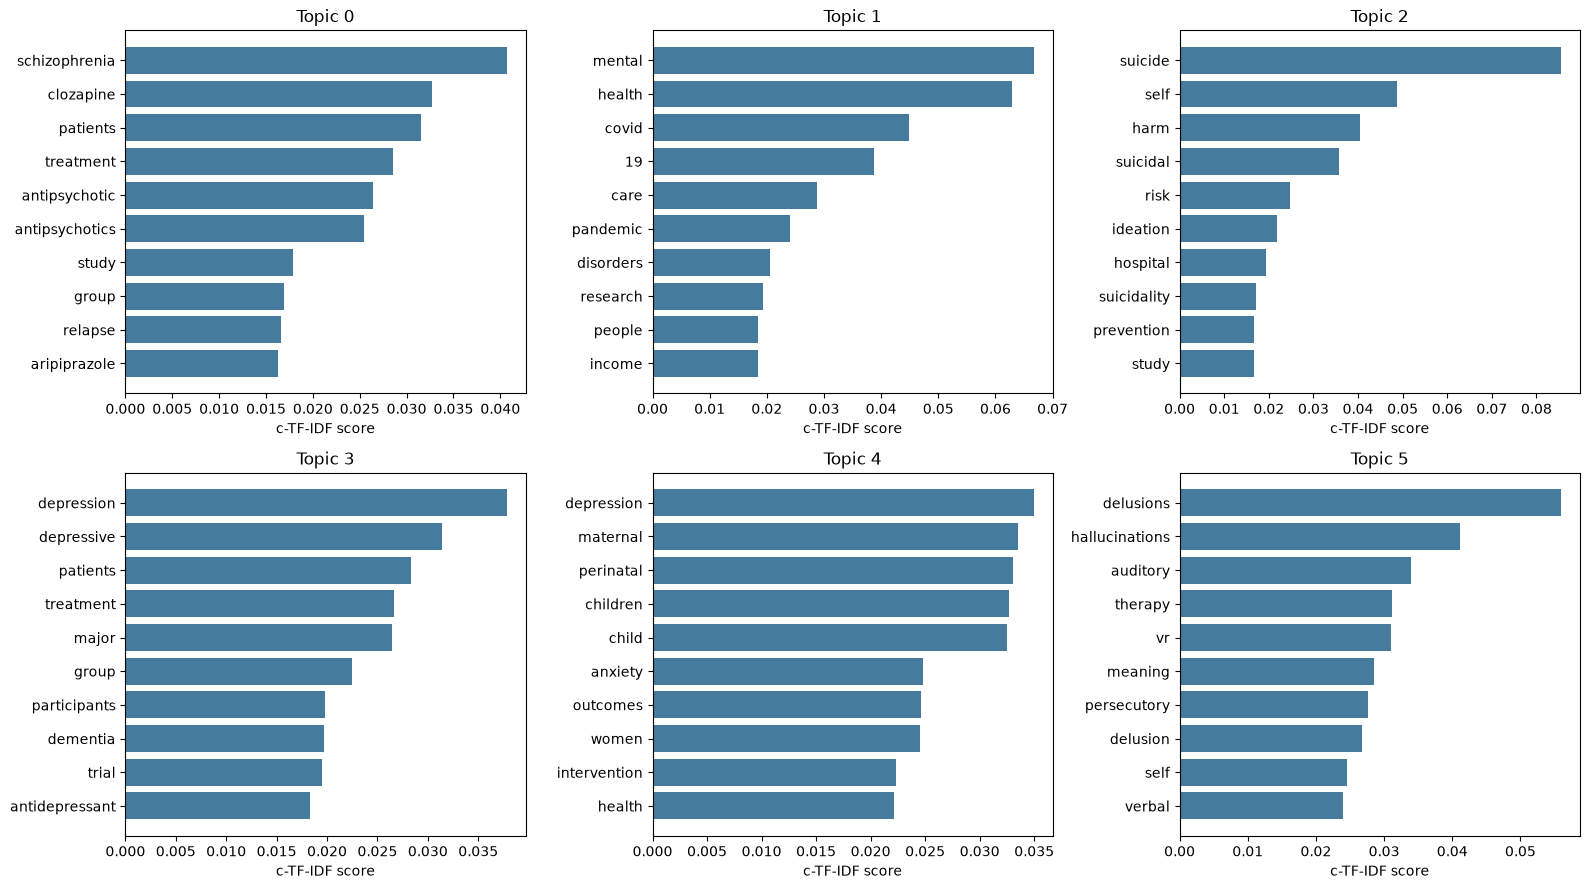

In [16]:
topic_model = globals().get("bertopic_model", globals().get("topic_model"))

if topic_model is None:
    raise NameError("Run the BERTopic creation cell first so `bertopic_model` exists.")

topics = getattr(topic_model, "topics_", None)
if topics is None:
    topics = cluster_labels

valid_topics = [t for t in sorted(set(topics)) if t != -1]
show_topics = valid_topics[: min(6, len(valid_topics))]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, topic_id in zip(axes, show_topics):
    words_scores = topic_model.get_topic(topic_id) or []
    words_scores = words_scores[:10]
    words = [w for w, _ in words_scores][::-1]
    scores = [s for _, s in words_scores][::-1]
    ax.barh(words, scores, color="#457b9d")
    ax.set_title(f"Topic {topic_id}")
    ax.set_xlabel("c-TF-IDF score")

for ax in axes[len(show_topics):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


### Which topics are closest to the aim?

Two complementary views:
- **Mean cosine similarity** - semantic closeness in embedding space
- **UMAP distance** - geometric closeness to the red aim point on the 2D map

In [17]:
from scipy.spatial.distance import cdist

In [18]:
aim_point = aim_viz.reshape(1, -1)

# Ensure we have topic labels available and attach them to articles_df
if "bertopic_topic" in articles_df.columns:
    labels = articles_df["bertopic_topic"].to_numpy()
elif "topic_labels" in globals() and len(topic_labels) == len(articles_df):
    labels = np.array(topic_labels)
elif "topics" in globals() and len(topics) == len(articles_df):
    labels = np.array(topics)
else:
    raise KeyError("No BERTopic labels found: provide 'bertopic_topic' column or 'topic_labels' / 'topics' variables matching articles_df length.")

tmp = articles_df.copy()
tmp["bertopic_topic"] = labels

# Ensure UMAP coords and similarity are present in the dataframe
if "umap_x" not in tmp.columns or "umap_y" not in tmp.columns:
    if "articles_2d" in globals():
        tmp["umap_x"] = articles_2d["UMAP1"].values
        tmp["umap_y"] = articles_2d["UMAP2"].values
    elif "viz_embeddings" in globals():
        tmp["umap_x"] = viz_embeddings[:, 0]
        tmp["umap_y"] = viz_embeddings[:, 1]
    else:
        raise KeyError("No 2D UMAP embeddings found: provide 'articles_2d' or 'viz_embeddings'.")

if "similarity_to_aim" not in tmp.columns and "articles" in globals():
    tmp["similarity_to_aim"] = articles["similarity_to_aim"].values

topic_stats = (
    tmp[tmp["bertopic_topic"] != -1]
    .groupby("bertopic_topic")
    .agg(
        n_articles=("pmid", "count"),
        mean_similarity=("similarity_to_aim", "mean"),
        median_similarity=("similarity_to_aim", "median"),
        mean_umap_x=("umap_x", "mean"),
        mean_umap_y=("umap_y", "mean"),
    )
    .reset_index()
)

topic_centers = topic_stats[["mean_umap_x", "mean_umap_y"]].to_numpy()
topic_stats["distance_to_aim_umap"] = cdist(topic_centers, aim_point).flatten()
topic_stats["label"] = topic_stats.apply(lambda r: f"Topic {int(r['bertopic_topic'])} (n={int(r['n_articles'])})", axis=1)

topic_stats.sort_values("mean_similarity", ascending=False).head(10)

,bertopic_topic,n_articles,mean_similarity,median_similarity,mean_umap_x,mean_umap_y,distance_to_aim_umap,label
6,6,20,0.443649,0.466728,8.744276,-3.164274,1.588775,Topic 6 (n=20)
1,1,49,0.442224,0.454632,5.571483,-2.882316,2.499407,Topic 1 (n=49)
17,17,6,0.429693,0.406158,6.508875,-2.286067,1.408335,Topic 17 (n=6)
0,0,55,0.428058,0.429530,10.543470,-2.285198,2.729416,Topic 0 (n=55)
5,5,22,0.407409,0.424372,8.875068,-0.326461,1.838698,Topic 5 (n=22)
3,3,42,0.393787,0.397454,7.616236,-3.855244,2.016680,Topic 3 (n=42)
13,13,11,0.389463,0.378646,7.006726,-1.922554,0.844875,Topic 13 (n=11)
7,7,19,0.369900,0.370821,8.551859,-1.213839,0.949608,Topic 7 (n=19)
2,2,47,0.368524,0.366401,3.151221,-2.042648,4.701295,Topic 2 (n=47)
11,11,15,0.365745,0.373495,4.378613,-2.190319,3.486489,Topic 11 (n=15)


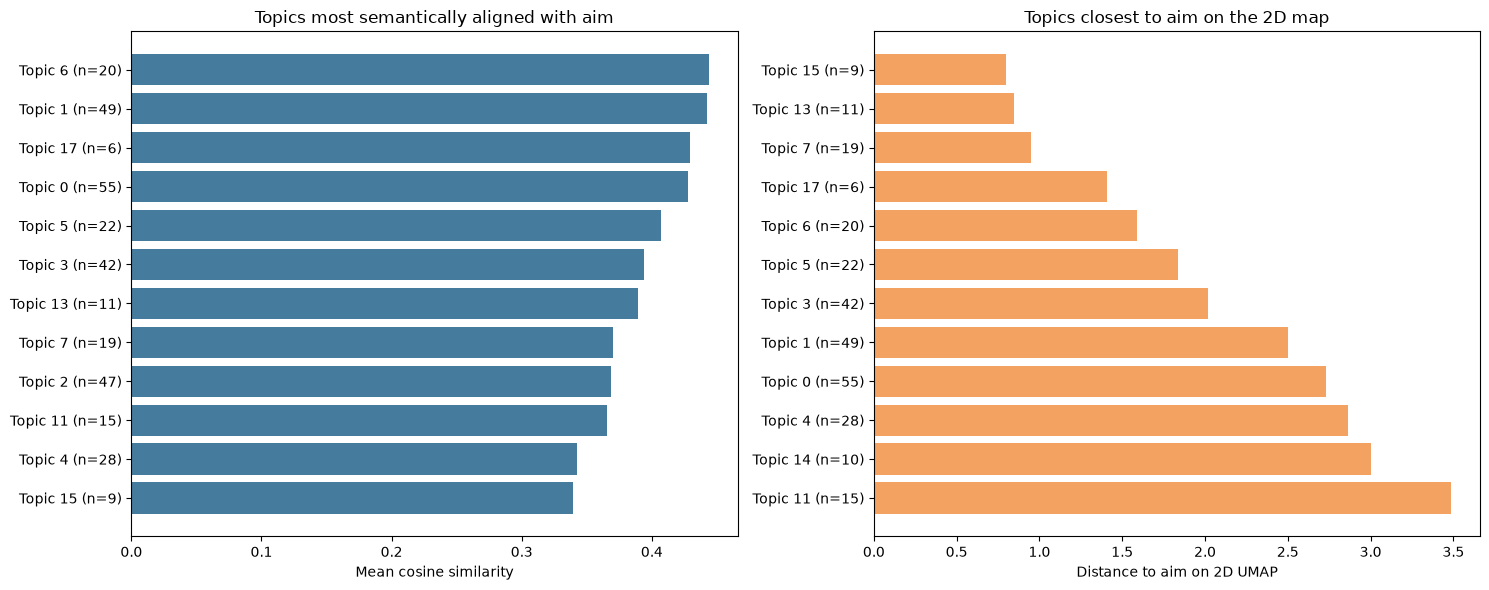

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar: mean similarity per topic (higher = closer to aim semantically)
plot_df = topic_stats.sort_values("mean_similarity", ascending=True).tail(12)
axes[0].barh(plot_df["label"], plot_df["mean_similarity"], color="#457b9d")
axes[0].set_xlabel("Mean cosine similarity")
axes[0].set_title("Topics most semantically aligned with aim")

# Bar: UMAP distance to aim (lower = closer on the map)
plot_df2 = topic_stats.sort_values("distance_to_aim_umap", ascending=False).tail(12)
axes[1].barh(plot_df2["label"], plot_df2["distance_to_aim_umap"], color="#f4a261")
axes[1].set_xlabel("Distance to aim on 2D UMAP")
axes[1].set_title("Topics closest to aim on the 2D map")

plt.tight_layout()
plt.show()

### Similarity vs BERTopic topic (boxplot)

Shows how aligned each topic is with the journal aim - useful for your report discussion.

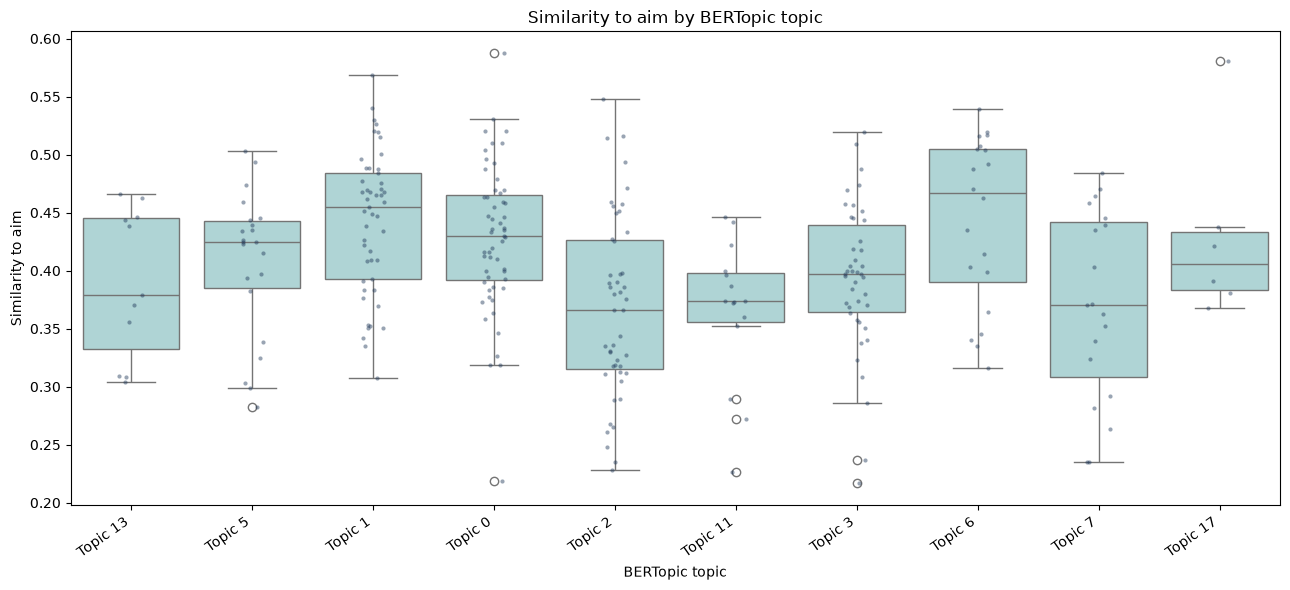

In [20]:
plot_topics = (
    tmp[tmp["bertopic_topic"] != -1]
    .groupby("bertopic_topic")["similarity_to_aim"]
    .median()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
subset = tmp[tmp["bertopic_topic"].isin(plot_topics)].copy()
subset["topic_label"] = subset["bertopic_topic"].map(lambda x: f"Topic {x}")

plt.figure(figsize=(13, 6))
sns.boxplot(data=subset, x="topic_label", y="similarity_to_aim", color="#a8dadc")
sns.stripplot(data=subset, x="topic_label", y="similarity_to_aim", color="#1d3557", alpha=0.45, size=3)
plt.title("Similarity to aim by BERTopic topic")
plt.xlabel("BERTopic topic")
plt.ylabel("Similarity to aim")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()



### BERTopic built-in visuals

In [21]:
from bertopic import BERTopic
import nbformat
import sys
import nbformat

import plotly.io as pio

In [22]:
import plotly.io as pio

In [23]:
import nbformat

In [24]:
import pandas as pd
import numpy as np

In [25]:
# Load docs only if they do not already exist
if "docs" not in globals():
    articles_df = pd.read_csv(WORKING_DATA)
    docs = (
        articles_df["title"].fillna("")
        + " "
        + articles_df["abstract"].fillna("")
    ).str.strip().tolist()

# Build BERTopic model only if it doesn't already exist
if "topic_model" not in globals():

    from bertopic_articles import (
        umap_articles,
        hdbscan_articles,
        bertopic_articles,
    )

    if "article_embeddings" not in globals():
        article_embeddings = np.load(ARTICLE_EMBEDDINGS)

    if "aim_embedding" not in globals():
        aim_embedding = np.load(AIM_EMBEDDING)

    umap_model, cluster_embeddings, *_ = umap_articles(
        article_embeddings,
        aim_embedding,
    )

    hdbscan_model, cluster_labels = hdbscan_articles(
        cluster_embeddings
    )

    topic_model, topic_labels, topic_probs = bertopic_articles(
        umap_model,
        hdbscan_model,
        docs,
        article_embeddings,
    )

# Hierarchy
hierarchical_topics = topic_model.hierarchical_topics(docs)
fig = topic_model.visualize_hierarchy(
    hierarchical_topics=hierarchical_topics
)
fig.show()
#Visualize topics
viz_topics = topic_model.visualize_topics()
viz_topics.show()
#Heatmap
topic_model.visualize_heatmap()


100%|██████████| 17/17 [00:00<00:00, 945.28it/s]


In [26]:
import plotly.express as px

# Use existing labels and embeddings without relying on `df`
clusters = np.asarray(cluster_labels if "cluster_labels" in globals() else labels)
n = len(clusters)

if "articles_2d" in globals():
    coords = articles_2d[["UMAP1", "UMAP2"]].to_numpy() if isinstance(articles_2d, pd.DataFrame) else np.asarray(articles_2d)
elif "embeddings_2d" in globals():
    coords = embeddings_2d[["UMAP1", "UMAP2"]].to_numpy()
elif "viz_embeddings" in globals():
    coords = np.asarray(viz_embeddings)
else:
    raise NameError("No 2D embeddings found (articles_2d / embeddings_2d / viz_embeddings).")

# Drop the extra aim row when present
coords = coords[:n]

if "articles" in globals() and "title" in articles.columns:
    titles = articles["title"].astype(str).tolist()[:n]
elif "articles_df" in globals() and "title" in articles_df.columns:
    titles = articles_df["title"].astype(str).tolist()[:n]
elif "docs_for_hierarchy" in globals():
    titles = docs_for_hierarchy[:n]
else:
    titles = [f"Doc {i}" for i in range(n)]

plot_df = pd.DataFrame({
    "x": coords[:, 0],
    "y": coords[:, 1],
    "cluster": clusters,
    "title": titles
})

fig = px.scatter(
    plot_df,
    x="x",
    y="y",
    color="cluster",
    hover_data=["title"]
)

fig.show()

In [27]:
cluster_counts = pd.Series(clusters).value_counts().sort_index()
print(f"Cluster counts: {cluster_counts}")
display()

Cluster counts: -1     112
 0       9
 1      16
 2       9
 3      14
 4      15
 5      18
 6       8
 7      35
 8      14
 9      12
 10      8
 11     52
 12     65
 13     30
 14     17
 15     49
 16     15
 17     21
Name: count, dtype: int64
